<a href="https://colab.research.google.com/github/nicolagherardi/AI_course_test/blob/main/Assignment_1_Gherardi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Assignment 1: Demand prediction of bike sharing system**

Bike sharing services are nowadays spread all over the world. They are beneficial for cities as they offer a climate neutral and healthy way of transportation. Moreover, similar to e-scooters, for the companies and transportation researchers they generate valuable data. This includes the trip route, trip origins and destinations, duration, and much more.

In this assignment we use a public bike sharing dataset from Washington, D.C., USA. published by Fanaee-T, H. (2013). Bike Sharing [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5W894.

## Your Task

Your task in this assignment is:

1) to predict the demand of hourly rentals (**target-column: cnt**) using the [XGBoost](https://xgboost.readthedocs.io/en/stable/) and linear regression model. In this notebook we have provided you with the basic structure how to approach the problem. Feel free to reuse and improve parts of the exercise material.

2) After you have created the model please upload your code to Github and post the link to the notebook in the corresponding forum for the assignment with a short text describing how you have solved the task.

## Load data

You can also find more information about the data and the columns at: https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset

In [1]:
import pandas as pd

url = 'https://raw.githubusercontent.com/zhenliangma/Applied-AI-in-Transportation/master/Exercise_2_regression_model/Exercise2BikeSharing.csv'
df = pd.read_csv(url)

#df = pd.read_csv('Exercise2BikeSharing.csv')
df.head(5)

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [2]:
df.shape

(17379, 17)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


## Data visualization

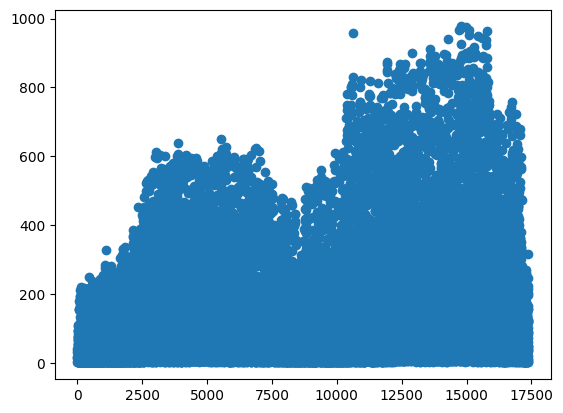

In [4]:
import matplotlib.pyplot as plt #to visualize data
plt.scatter(df['instant'], df['cnt'])
plt.show()

- Target: `cnt` (count of total rental bikes including both casual and registered)
- Predictors: weather (`temp`, `atemp`, `hum`, `windspeed`, `weathersit`), calendar (`hr`, `weekday`, `workingday`, `holiday`, `season`), and `yr`.
- We keep it simple; you can expand features (e.g., interactions) later.

## Managing the dataset

In [5]:
from sklearn.model_selection import train_test_split
target = 'cnt'

X = df.copy()
y = df[target].astype(float)

X.drop(columns=[target, 'instant', 'dteday', 'casual', 'registered'], inplace=True)
X.head()


,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed
0,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0
1,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0
2,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0
3,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0
4,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0


## Data Processing / Feature Engineering

Before training the model think about data processing and feature engineering steps if applicable, such as:
- adding/removal of features
- normalization
- one hot encoding
- ...


# Correlation matrix

In [6]:
df_for_corr=df.copy()
df_for_corr=df_for_corr.drop(columns=['instant', 'dteday','registered','casual'], axis=1)
corr_matrix = df_for_corr.corr()
corr_matrix['cnt'].sort_values(ascending=False)

,cnt
cnt,1.000000
temp,0.404772
atemp,0.400929
hr,0.394071
yr,0.250495
season,0.178056
mnth,0.120638
windspeed,0.093234
workingday,0.030284
weekday,0.026900


## Dummy variables

In [7]:
# AI to code dummy variables creation
import pandas as pd
X_encoded = pd.get_dummies(X, columns=['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit'], dtype=int)
print(X_encoded.describe())

               temp         atemp           hum     windspeed      season_1  \
count  17379.000000  17379.000000  17379.000000  17379.000000  17379.000000   
mean       0.496987      0.475775      0.627229      0.190098      0.244088   
std        0.192556      0.171850      0.192930      0.122340      0.429557   
min        0.020000      0.000000      0.000000      0.000000      0.000000   
25%        0.340000      0.333300      0.480000      0.104500      0.000000   
50%        0.500000      0.484800      0.630000      0.194000      0.000000   
75%        0.660000      0.621200      0.780000      0.253700      0.000000   
max        1.000000      1.000000      1.000000      0.850700      1.000000   

           season_2      season_3      season_4          yr_0          yr_1  \
count  17379.000000  17379.000000  17379.000000  17379.000000  17379.000000   
mean       0.253697      0.258703      0.243512      0.497439      0.502561   
std        0.435139      0.437935      0.429214    

## Train / Test split

In [8]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

## Hyperparameter optimization
Hyperparameter tuning helps find the best set of hyperparameters for your model. Use Grid Search or Random Search with Cross Validation from scikit-learn to search for the best combination of parameters.

In [9]:
# AI to code the XGBoost and to optimize its parameters

from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

xgb = XGBRegressor()

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [2, 3, 5],
    'learning_rate': [0.01, 0.05, 0.1]
}

grid_search_xgb = GridSearchCV(estimator=xgb, param_grid=param_grid, cv=5)


## Train the XGBoost and Linear regression models
Now, create an XGBoost and linear regression model using the best parameters and train them using the training data.

## XGBoost

In [10]:
grid_search_xgb.fit(X_train, y_train)
grid_search_xgb.best_params_

{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300}

##Linear Regression

In [11]:
from sklearn.preprocessing import StandardScaler

# Normalize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
from sklearn.linear_model import LinearRegression

model_ols=LinearRegression()
model_ols.fit(X_train_scaled, y_train)

LinearRegression()

## Make predictions
Use the trained models to make predictions on the test data and compare the performance of the XGBoost and linear regression models using metrics like Mean Squared Error (MSE) and R-squared.

In [13]:
from sklearn.metrics import root_mean_squared_error, r2_score

# XGBoost predictions
y_pred_xgb = grid_search_xgb.best_estimator_.predict(X_test)

# Linear Regression predictions
y_pred_ols = model_ols.predict(X_test_scaled)

# Calculate metrics for XGBoost
rmse_xgb = root_mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost Model Performance:\n  Root Mean Squared Error: {rmse_xgb:.2f}\n  R-squared: {r2_xgb:.2f}")

# Calculate metrics for Linear Regression
rmse_ols = root_mean_squared_error(y_test, y_pred_ols)
r2_ols = r2_score(y_test, y_pred_ols)
n = len(y_test)
p = X_test_scaled.shape[1]
r2_adj_ols = 1 - (1 - r2_ols) * (n - 1) / (n - p - 1) #from notes of previous courses

print(f"\nLinear Regression Model Performance:\n  Root Mean Squared Error: {rmse_ols:.2f}\n  R-squared: {r2_ols:.2f}\n  R-squared_adj: {r2_adj_ols:.2f}")

XGBoost Model Performance:
  Root Mean Squared Error: 47.58
  R-squared: 0.93
3476
61

Linear Regression Model Performance:
  Root Mean Squared Error: 100.45
  R-squared: 0.68
  R-squared_adj: 0.68


## Visualize the predictions and compare the mdoels
Create a "Actual vs. Predicted Values" graph to give a visual inspection of the prediction quality.

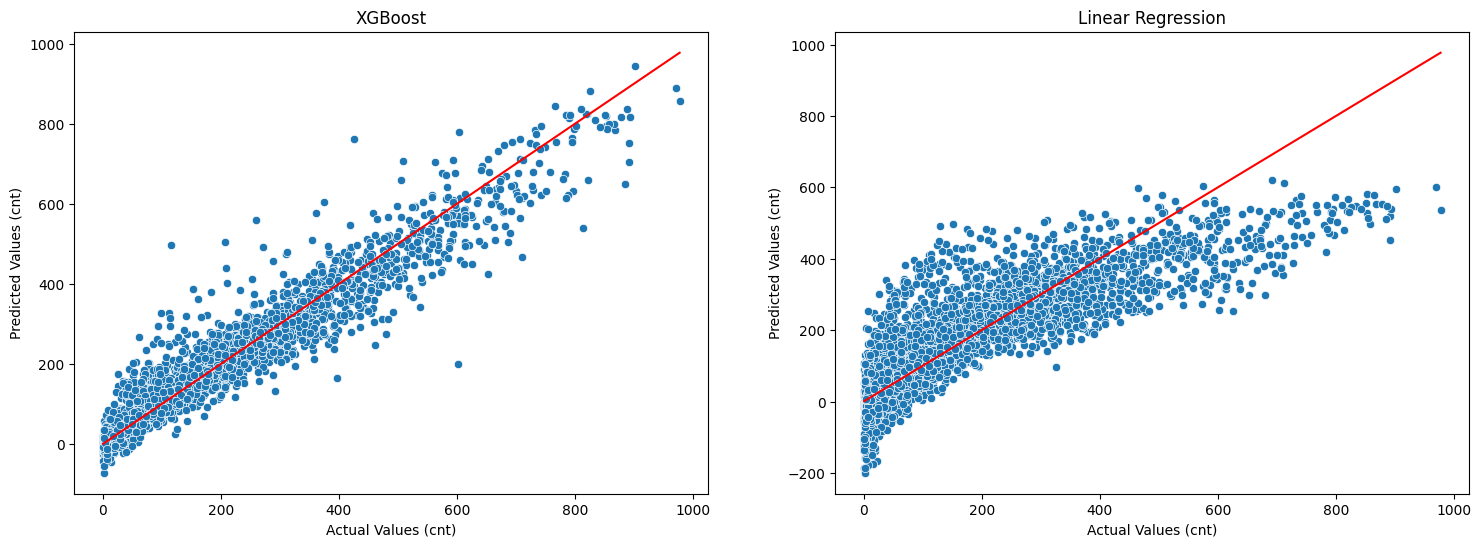

In [14]:
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot for XGBoost Model
sns.scatterplot(x=y_test, y=y_pred_xgb, ax=axes[0])
axes[0].set_title('XGBoost')
axes[0].set_xlabel('Actual Values (cnt)')
axes[0].set_ylabel('Predicted Values (cnt)')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r') # Line for perfect prediction

# Plot for Linear Regression Model
sns.scatterplot(x=y_test, y=y_pred_ols, ax=axes[1])
axes[1].set_title('Linear Regression')
axes[1].set_xlabel('Actual Values (cnt)')
axes[1].set_ylabel('Predicted Values (cnt)')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r') # Line for perfect prediction

